In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from model import SocialGPModel
from rewards import (
    make_parent_and_children_cholesky2,
    build_corr_matrix_option1,
    _min_max,
    generate_env,
)
from tqdm import tqdm
from joblib import Parallel, delayed

In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Grid Size Test

This notebook tests the effect of different grid sizes (11x11, 21x21, 31x31) on:
1. Environment correlation accuracy
2. Agent performance (cumulative reward)

In [4]:
# Setup correlation matrix
corr_matrix = build_corr_matrix_option1()
n_children = corr_matrix.shape[0] - 1
rho_true = corr_matrix[0]

# Grid sizes to test
grid_sizes = [11, 21, 31]

print(f"Testing grid sizes: {grid_sizes}")
print(f"Target correlations: {rho_true}")

Testing grid sizes: [11, 21, 31]
Target correlations: [ 1.   0.6  0.  -0.6]


In [ ]:
def get_agent0_rho(model):
    agent = model.grid.agents[0]
    neighbors = [n.agents[0].unique_id for n in model.grid[agent.cell.coordinate].neighborhood]
    if agent._rho_updater is None:
        return np.array(agent.rho, dtype=float)
    return agent._rho_updater.get_rho_vector(neighbors)


def run_one_simulation(grid_size, parent, child_maps, n_steps=15, seed=0):
    """Run one simulation for a given grid size."""
    m = SocialGPModel(
        n=n_children + 1,
        child_maps=[parent] + child_maps,
        network_type="directed_one_to_four",
        rho_update_rule=None,
        rho=rho_true,
        model_type="SG-ICM",
        rho_update_init=0.0,
        rho_update_sigma_zeta=1e-4,
        rho_update_basis="full",
        tau=0.03,
        beta_private=0.33,
        length_scale_private=1.11,
        length_scale_is_identical=True,
        seed=seed,
    )

    rho_history = []
    for _ in range(n_steps):
        m.step()
        rho_history.append(get_agent0_rho(m))

    df = m.datacollector.get_agent_vars_dataframe().reset_index()
    df["grid_size"] = grid_size
    df["grid_size_label"] = f"{grid_size}x{grid_size}"
    df["seed"] = seed
    return df, np.array(rho_history)

In [ ]:
def process_one_seed(env_seed, grid_sizes_to_test):
    """Process one seed across all grid sizes."""
    local_results = []
    local_rhos = []

    for grid_size in grid_sizes_to_test:
        # Generate environment for this grid size
        parent, child_maps = generate_env(
            env_seed, 
            np.array([1, 0.6, 0.0, -0.6]), 
            corr_matrix,
            grid_size=grid_size
        )
        
        # Run simulation
        df, rho_hist = run_one_simulation(
            grid_size,
            parent,
            child_maps,
            n_steps=15,
            seed=env_seed,
        )
        local_results.append(df)
        local_rhos.append(
            {
                "grid_size": grid_size,
                "grid_size_label": f"{grid_size}x{grid_size}",
                "seed": env_seed,
                "rho_history": rho_hist,
            }
        )
    
    return local_results, local_rhos

In [7]:
# Run simulations in parallel
n_envs = 1000
n_steps = 15

parallel_outputs = Parallel(n_jobs=-1)(
    delayed(process_one_seed)(seed, grid_sizes) for seed in tqdm(range(n_envs))
)

all_results = []
rho_histories = []

for seed_dfs, seed_rhos in parallel_outputs:
    all_results.extend(seed_dfs)
    rho_histories.extend(seed_rhos)

results = pd.concat(all_results, ignore_index=True)
results.head()

100%|██████████| 1000/1000 [00:41<00:00, 24.33it/s]


,Step,AgentID,choice,reward,cumulative_reward,model_type,tau,neg_log_likelihood,last_choice_distance_private,avg_choice_distance_private,nearest_choice_distance_private,last_choice_distance_social,avg_choice_distance_social,nearest_choice_distance_social,grid_size,grid_size_label,seed
0,1,1,"(9, 9)",0.528843,0.528843,SG-ICM,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,11,11x11,0
1,1,2,"(5, 4)",0.859409,0.859409,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,11,11x11,0
2,1,3,"(9, 8)",0.993539,0.993539,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,11,11x11,0
3,1,4,"(3, 10)",0.161161,0.161161,AS,0.03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,11,11x11,0
4,2,1,"(2, 10)",0.346999,0.875842,SG-ICM,0.03,3.060515,7.071068,7.071068,7.071068,4.996105,4.996105,1.0,11,11x11,0


## Agent Performance: Reward and Cumulative Reward Over Time

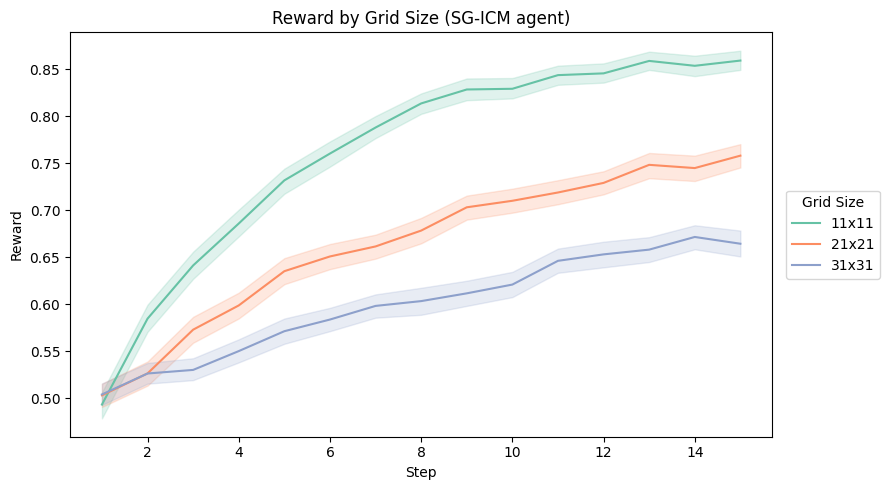

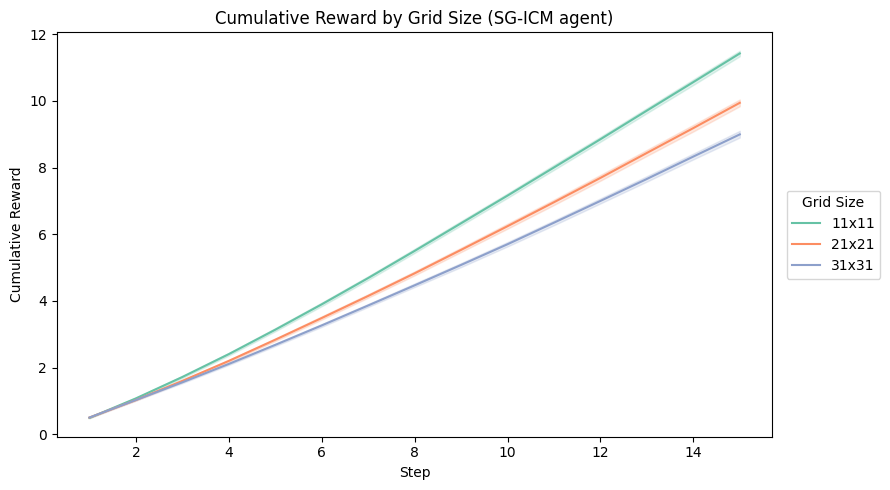

In [8]:
def plot_reward_by_grid_size(df, y_col="reward", figsize=(9, 5)):
    """Plot reward over time for different grid sizes."""
    # Select SG-ICM agent only
    plot_df = df[(df["model_type"] == "SG-ICM") | (df["model_type"] == "SG")].copy()
    plot_df = plot_df.dropna(subset=["Step", y_col, "grid_size_label"])
    
    if plot_df.empty:
        print("No data available for plotting.")
        return

    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(
        data=plot_df,
        x="Step",
        y=y_col,
        hue="grid_size_label",
        hue_order=[f"{gs}x{gs}" for gs in grid_sizes],
        ax=ax,
        palette='Set2'
    )
    ax.set_title(f"{y_col.replace('_', ' ').title()} by Grid Size (SG-ICM agent)")
    ax.set_xlabel("Step")
    ax.set_ylabel(y_col.replace("_", " ").title())
    ax.legend(
        title="Grid Size",
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0,
    )
    plt.tight_layout()
    plt.show()

plot_reward_by_grid_size(results, y_col="reward")
plot_reward_by_grid_size(results, y_col="cumulative_reward")

## Final Cumulative Reward Comparison

/var/folders/jb/dqyqqwzs7s335q1r73w5cpg00000gn/T/ipykernel_35951/1682704706.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


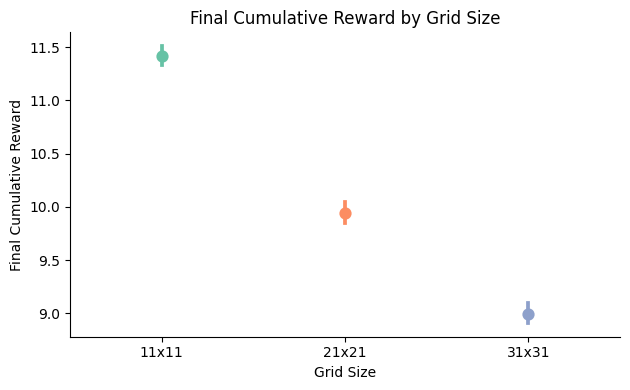

In [9]:
def plot_final_cumreward_by_grid_size(df):
    """Plot final cumulative reward by grid size."""
    plot_df = df[(df["model_type"] == "SG-ICM") | (df["model_type"] == "SG")].copy()
    
    if plot_df.empty:
        print("No data available for plotting.")
        return

    group_cols = ["seed", "grid_size_label"]
    final_step = plot_df.groupby(group_cols)["Step"].transform('max')
    last = plot_df[plot_df['Step'] == final_step].copy()
    last = last.dropna(subset=['grid_size_label', 'cumulative_reward'])
    
    if last.empty:
        print("No final-step data to plot.")
        return

    sns.catplot(
        data=last,
        kind='point',
        x='grid_size_label',
        y='cumulative_reward',
        order=[f"{gs}x{gs}" for gs in grid_sizes],
        height=4,
        aspect=1.6,
        linestyle='none',
        estimator='mean',
        errorbar=('ci', 95),
        palette='Set2'
    )

    plt.xlabel('Grid Size')
    plt.ylabel('Final Cumulative Reward')
    plt.title('Final Cumulative Reward by Grid Size')
    plt.tight_layout()
    plt.show()

plot_final_cumreward_by_grid_size(results)

## Environment Correlation Accuracy Analysis

In [ ]:
def measure_env_correlations_with_filtering(grid_size, corr_matrix, n_seeds=50):
    """Measure actual correlations in FILTERED generated environments (using generate_env)."""
    results = []
    target_rho = np.array([1, 0.6, 0.0, -0.6])

    for seed in range(n_seeds):
        # Use generate_env with filtering (same as actual simulations)
        parent_norm, child_maps_norm = generate_env(
            seed, 
            target_rho, 
            corr_matrix,
            grid_size=grid_size,
            max_tries=10000,
            tol=0.10
        )
        
        # Measure correlations (already normalized by generate_env)
        flat_maps = [parent_norm.ravel()] + [c.ravel() for c in child_maps_norm]
        R_actual = np.corrcoef(flat_maps)

        # Store agent 0's correlations with other agents
        for j in range(1, corr_matrix.shape[0]):
            results.append({
                'grid_size': f'{grid_size}x{grid_size}',
                'agent_pair': f'A0→A{j}',
                'target': corr_matrix[0, j],
                'actual': R_actual[0, j],
                'error': abs(R_actual[0, j] - corr_matrix[0, j])
            })

    return pd.DataFrame(results)

print("Measuring correlation accuracy for FILTERED environments (same as used in simulations)...")
R = build_corr_matrix_option1()
corr_results = pd.concat([
    measure_env_correlations_with_filtering(size, R, n_seeds=50)
    for size in grid_sizes
], ignore_index=True)

print(f"Collected {len(corr_results)} correlation measurements")
print(f"\nMean error by grid size:")
print(corr_results.groupby('grid_size')['error'].mean())
corr_results.head()

/var/folders/jb/dqyqqwzs7s335q1r73w5cpg00000gn/T/ipykernel_35951/2824557119.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


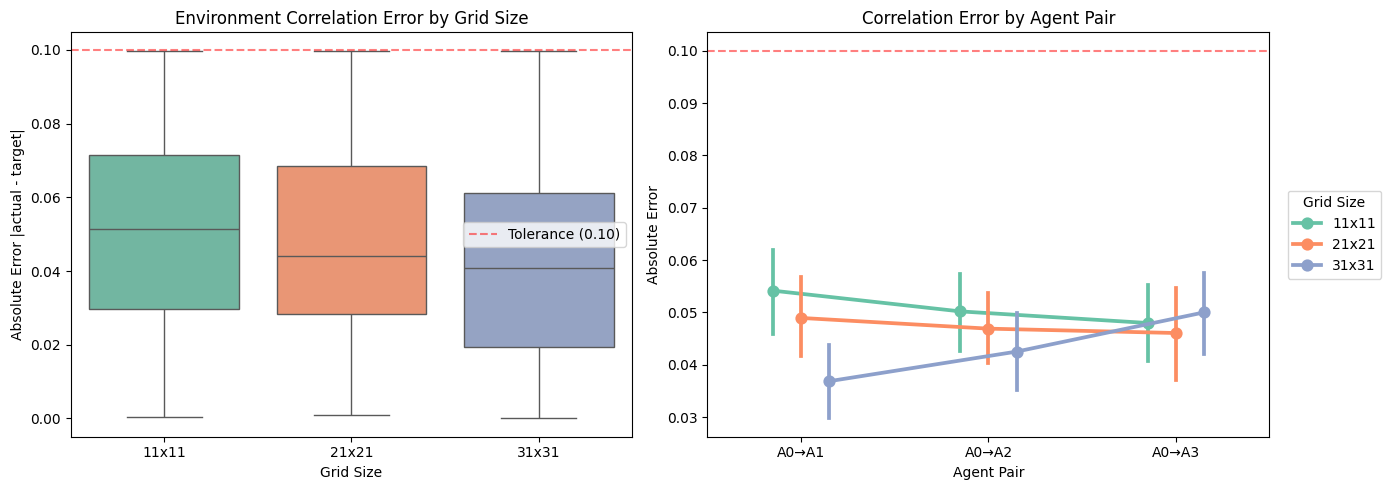

In [11]:
# Plot correlation error analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Error distribution by grid size
sns.boxplot(
    data=corr_results,
    x='grid_size',
    y='error',
    order=[f"{gs}x{gs}" for gs in grid_sizes],
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Environment Correlation Error by Grid Size')
axes[0].set_xlabel('Grid Size')
axes[0].set_ylabel('Absolute Error |actual - target|')
axes[0].axhline(y=0.10, color='red', linestyle='--', alpha=0.5, label='Tolerance (0.10)')
axes[0].legend()

# Plot 2: Error by agent pair
sns.pointplot(
    data=corr_results,
    x='agent_pair',
    y='error',
    hue='grid_size',
    hue_order=[f"{gs}x{gs}" for gs in grid_sizes],
    ax=axes[1],
    dodge=0.3,
    palette='Set2'
)
axes[1].set_title('Correlation Error by Agent Pair')
axes[1].set_xlabel('Agent Pair')
axes[1].set_ylabel('Absolute Error')
axes[1].axhline(y=0.10, color='red', linestyle='--', alpha=0.5)
axes[1].legend(title='Grid Size', bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.tight_layout()
plt.show()

## Summary Statistics

In [12]:
# Summary of final cumulative rewards
plot_df = results[(results["model_type"] == "SG-ICM") | (results["model_type"] == "SG")].copy()
group_cols = ["seed", "grid_size_label"]
final_step = plot_df.groupby(group_cols)["Step"].transform('max')
last = plot_df[plot_df['Step'] == final_step].copy()

print("Final Cumulative Reward by Grid Size:")
print(last.groupby('grid_size_label')['cumulative_reward'].describe())

print("\nCorrelation Error by Grid Size:")
print(corr_results.groupby('grid_size')['error'].describe())

Final Cumulative Reward by Grid Size:
                  count       mean       std       min        25%        50%        75%        max
grid_size_label                                                                                   
11x11            1000.0  11.419977  1.395287  6.272160  10.581612  11.639935  12.439199  14.287713
21x21            1000.0   9.940334  1.642299  5.216655   8.811557  10.024332  11.196936  13.927781
31x31            1000.0   8.993079  1.524786  5.359399   7.893489   8.943890  10.069628  12.977323

Correlation Error by Grid Size:
           count      mean       std       min       25%       50%       75%       max
grid_size                                                                             
11x11      150.0  0.050792  0.027348  0.000407  0.029634  0.051337  0.071600  0.099617
21x21      150.0  0.047319  0.027047  0.000857  0.028445  0.044056  0.068382  0.099592
31x31      150.0  0.043142  0.026761  0.000041  0.019530  0.040962  0.061063  0.099798